# Notebook 04: Supervised Machine Learning — Hospital Tier Prediction
**Project:** Predicting the DOH Hospital Tier Available per LGU from Socioeconomic Features

**Research Question:** *Can the socioeconomic profile of an LGU — its poverty rate, birth demand, population size, and growth — predict the hospital tier it warrants? And which LGUs are structurally underserved?*

---

## Design Rationale

### Why only socioeconomic features?

Previous versions included 18 OSM infrastructure counts (banks, restaurants, fast-food outlets, etc.). These were removed for two reasons:

1. **No interpretable insight.** A model that tells you "more fast-food outlets predicts a higher-tier hospital" gives you no actionable finding. The question is whether *socioeconomic need* — poverty, birth demand, population growth — predicts hospital availability. OSM features are noise relative to that question.

2. **They encode wealth, not need.** OSM amenity density is a proxy for urbanisation and economic development. Including them alongside poverty and population makes it impossible to disentangle whether the model is learning about healthcare need or simply about how developed an LGU is.

The 9 socioeconomic features (3 poverty years, 3 birth residence columns, 2 population years, 1 growth rate) are cleanly motivated and interpretable.

### Why PCA on the 9 features?

The 9 socioeconomic features are highly collinear:
- `births_residence_both/male/female` are nearly perfect linear combinations of each other
- `population_2020` and `population_2024` are nearly identical
- `poverty_incidence_2018/2021/2023` are strongly correlated across years

PCA on these 9 features yields **4 components explaining 94.2% of variance**, each with a clear interpretation:

| Component | Variance | Interpretation |
|-----------|----------|---------------|
| PC1 | 46.3% | **Birth demand** (births_residence all load +0.45) |
| PC2 | 25.7% | **Poverty** (all three poverty years load +0.52–0.54) |
| PC3 | 11.6% | **City size** (population_2020/2024 each load +0.57) |
| PC4 | 10.5% | **Growth pressure** (pop_growth_rate loads +0.95) |

These 4 PCs are used as inputs to all five models. This connects directly to `03_preprocessing.py` which performed PCA on the full 27-feature set — here we apply the same technique to the interpretable subset and use the resulting components for modelling.

### Target: Ordinal Hospital Tier

| Tier | Definition | LGUs | % |
|------|-----------|------|---|
| 0 | No hospital | 1,339 | 82.2% |
| 1 | ≥1 Level 1 | 196 | 12.0% |
| 2 | ≥1 Level 2 | 73 | 4.5% |
| 3 | ≥1 Level 3 | 21 | 1.3% |

## Notebook Structure

| # | Section |
|---|---------|
| 1 | Setup and Data Loading |
| 2 | Feature Engineering and Imputation |
| 3 | Target Variable |
| 4 | Standardisation and PCA (connecting to Script 03) |
| 5 | Train / Test Split |
| 6 | kNN Classification |
| 7 | Logistic Regression — L2 |
| 8 | Logistic Regression — L1 (liblinear, OvR) |
| 9 | Random Forest |
| 10 | Gradient Boosted Trees |
| 11 | Model Comparison |
| 12 | Underserved LGU Identification |
| 13 | Novelty — Expected Tier and Poverty Equity Analysis |
| 14 | Conclusion |


---
## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

print("Libraries loaded.")


Libraries loaded.


In [2]:
DB_PATH   = os.path.join('data', 'processed', 'hospital_data.db')
XLSX_PATH = os.path.join('data', 'clean', 'final_dataset_clean.xlsx')

if os.path.exists(DB_PATH):
    conn = sqlite3.connect(DB_PATH)
    df   = pd.read_sql('SELECT * FROM lgu_merged', conn)
    conn.close()
    print(f"Loaded from SQLite: {df.shape[0]} LGUs x {df.shape[1]} cols")
else:
    df = pd.read_excel(XLSX_PATH)
    if 'province_x' in df.columns:
        df = df.rename(columns={'province_x': 'province'})
    print(f"Loaded from XLSX: {df.shape[0]} LGUs x {df.shape[1]} cols")


Loaded from SQLite: 1629 LGUs x 52 cols


---
## 2. Feature Engineering and Imputation

In [3]:
# ── 9 socioeconomic features ────────────────────────────────────────────
FEATURES = [
    'population_2020',
    'population_2024',
    'pop_growth_rate_pct',
    'poverty_incidence_2018_pct',
    'poverty_incidence_2021_pct',
    'poverty_incidence_2023_pct',
    'births_residence_both',
    'births_residence_male',
    'births_residence_female',
]
print(f"Features: {len(FEATURES)}")
for f in FEATURES:
    print(f"  {f}")
print()
print("OSM infrastructure counts (18 columns) are excluded.")
print("Reason: 'bank_per10k predicts hospital tier' is not an interpretable finding.")
print("The research question is about socioeconomic need, not proxy development indicators.")


Features: 9
  population_2020
  population_2024
  pop_growth_rate_pct
  poverty_incidence_2018_pct
  poverty_incidence_2021_pct
  poverty_incidence_2023_pct
  births_residence_both
  births_residence_male
  births_residence_female

OSM infrastructure counts (18 columns) are excluded.
Reason: 'bank_per10k predicts hospital tier' is not an interpretable finding.
The research question is about socioeconomic need, not proxy development indicators.


In [4]:
# ── Impute: regional median for poverty and birth columns ────────────────
IMPUTE_COLS = [
    'poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct',
    'births_residence_both', 'births_residence_male', 'births_residence_female',
]
for col in IMPUTE_COLS:
    reg_med = df.groupby('region')[col].transform('median')
    df[col]  = df[col].fillna(reg_med).fillna(df[col].median())

print(f"Missing after imputation: {df[FEATURES].isnull().sum().sum()}")


Missing after imputation: 0


---
## 3. Target Variable: Ordinal Hospital Tier

In [5]:
# ── Construct ordinal tier ──────────────────────────────────────────────
df['tier'] = 0
df.loc[df['hospital_count_level1'] >= 1, 'tier'] = 1
df.loc[df['hospital_count_level2'] >= 1, 'tier'] = 2
df.loc[df['hospital_count_level3'] >= 1, 'tier'] = 3

_cols = list(dict.fromkeys(
    FEATURES + ['tier', 'city_municipality', 'region', 'poverty_incidence_2023_pct']
))
model_df = df[_cols].dropna(subset=FEATURES).copy().reset_index(drop=True)
print(f"Working dataset: {len(model_df)} LGUs")
print()
vc = model_df['tier'].value_counts().sort_index()
labels = {0:'No hospital', 1:'Level 1 (primary)', 2:'Level 2 (secondary)', 3:'Level 3 (tertiary)'}
for t, cnt in vc.items():
    print(f"  Tier {t} — {labels[t]:<26}  {cnt:>5} LGUs  ({cnt/len(model_df)*100:.1f}%)")


Working dataset: 1629 LGUs

  Tier 0 — No hospital                  1339 LGUs  (82.2%)
  Tier 1 — Level 1 (primary)             196 LGUs  (12.0%)
  Tier 2 — Level 2 (secondary)            73 LGUs  (4.5%)
  Tier 3 — Level 3 (tertiary)             21 LGUs  (1.3%)


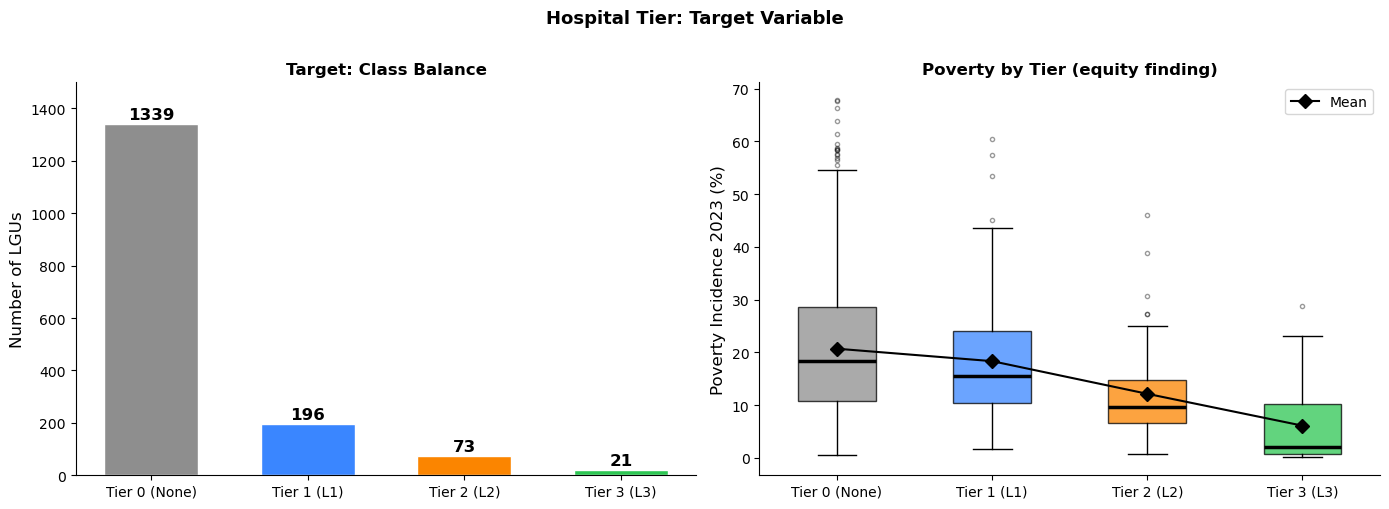

Poverty decreases monotonically with tier:
  Tier 0: mean=20.7%  median=18.5%
  Tier 1: mean=18.4%  median=15.6%
  Tier 2: mean=12.2%  median=9.7%
  Tier 3: mean=6.1%  median=2.1%


In [6]:
# ── Visualise: tier distribution and poverty by tier ─────────────────────
TIER_COLORS = ['#8e8e8e', '#3a86ff', '#fb8500', '#2dc653']
TIER_LBLS   = ['Tier 0 (None)', 'Tier 1 (L1)', 'Tier 2 (L2)', 'Tier 3 (L3)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = model_df['tier'].value_counts().sort_index()
bars = axes[0].bar(TIER_LBLS, counts.values, color=TIER_COLORS, edgecolor='white', width=0.6)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(cnt), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of LGUs', fontsize=12)
axes[0].set_title('Target: Class Balance', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, counts.max() * 1.12)
axes[0].spines[['top', 'right']].set_visible(False)

pov_data = [model_df[model_df['tier'] == t]['poverty_incidence_2023_pct'].dropna().values
            for t in range(4)]
bp = axes[1].boxplot(pov_data, labels=TIER_LBLS, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, c in zip(bp['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.75)
means = [v.mean() for v in pov_data]
axes[1].plot(range(1, 5), means, 'D-', color='black', ms=7, zorder=5, label='Mean')
axes[1].set_ylabel('Poverty Incidence 2023 (%)', fontsize=12)
axes[1].set_title('Poverty by Tier (equity finding)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Hospital Tier: Target Variable', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("Poverty decreases monotonically with tier:")
for t, vals in enumerate(pov_data):
    print(f"  Tier {t}: mean={vals.mean():.1f}%  median={np.median(vals):.1f}%")


---
## 4. Standardisation and PCA

This section connects directly to `03_preprocessing.py`. There, PCA was applied to the full 27-feature set (9 socioeconomic + 18 OSM). Here we apply the same technique to the 9 socioeconomic features alone, which gives us 4 interpretable components covering 94.2% of variance.

The 4 PCs have clean, named interpretations — unlike the 27-feature PCA where PCs were mixtures of OSM and socioeconomic signals:

- **PC1 — Birth Demand** (46.3%): all three birth residence columns load uniformly at +0.45
- **PC2 — Poverty** (25.7%): all three poverty years load at +0.52–0.54
- **PC3 — City Size** (11.6%): population 2020 and 2024 each load at +0.57
- **PC4 — Growth Pressure** (10.5%): pop_growth_rate loads at +0.95

These 4 PCs are the input to all five models below.


In [7]:
# ── Standardise (fit on train, transform both) ───────────────────────────
X_all = model_df[FEATURES]
y_all = model_df['tier']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42, stratify=y_all
)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_raw)
X_test_sc   = scaler.transform(X_test_raw)
X_all_sc    = scaler.transform(X_all)

print("Standardisation: fit on training set only, applied to both sets.")
print(f"  Train: {X_train_sc.shape}  mean~{X_train_sc.mean():.2e}  std~{X_train_sc.std():.3f}")
print(f"  Test:  {X_test_sc.shape}")


Standardisation: fit on training set only, applied to both sets.
  Train: (1221, 9)  mean~2.07e-17  std~1.000
  Test:  (408, 9)


In [8]:
# ── PCA: fit on train, transform both ────────────────────────────────────
pca         = PCA(n_components=4, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
X_all_pca   = pca.transform(X_all_sc)

evr = pca.explained_variance_ratio_
print(f"PCA fit on {len(X_train_raw)} training LGUs only.")
print(f"4 PCs explain {evr.sum()*100:.1f}% of variance in the 9 socioeconomic features.")
print()
print("Explained variance per component:")
for i, ev in enumerate(evr, 1):
    bar = chr(9608) * int(ev * 40)
    print(f"  PC{i}: {ev*100:5.1f}%  {bar}")


PCA fit on 1221 training LGUs only.
4 PCs explain 94.2% of variance in the 9 socioeconomic features.

Explained variance per component:
  PC1:  46.3%  ██████████████████
  PC2:  25.7%  ██████████
  PC3:  11.6%  ████
  PC4:  10.5%  ████


In [9]:
# ── PC loading matrix and interpretation ─────────────────────────────────
W = pd.DataFrame(pca.components_,
                  index=['PC1', 'PC2', 'PC3', 'PC4'],
                  columns=FEATURES)

print("PC Loading Matrix (how original features map to each component):")
print(W.round(2).to_string())
print()
print("Interpretation:")
interpretations = {
    'PC1': 'Birth Demand  -- all birth_residence cols load +0.45 uniformly',
    'PC2': 'Poverty       -- all three poverty years load +0.52 to +0.54',
    'PC3': 'City Size     -- population_2020/2024 each load +0.57',
    'PC4': 'Growth Pressure -- pop_growth_rate_pct loads +0.95',
}
for pc, interp in interpretations.items():
    print(f"  {pc}: {interp}")

print()
print("These 4 PCs are used as input features for all five models below.")


PC Loading Matrix (how original features map to each component):
     population_2020  population_2024  pop_growth_rate_pct  poverty_incidence_2018_pct  poverty_incidence_2021_pct  poverty_incidence_2023_pct  births_residence_both  births_residence_male  births_residence_female
PC1             0.37             0.37                -0.02                       -0.20                       -0.21                       -0.19                   0.45                   0.45                     0.45
PC2             0.18             0.19                 0.22                        0.52                        0.54                        0.52                   0.13                   0.13                     0.13
PC3             0.57             0.57                -0.13                       -0.04                       -0.03                       -0.02                  -0.33                  -0.33                    -0.33
PC4             0.04             0.05                 0.95                     

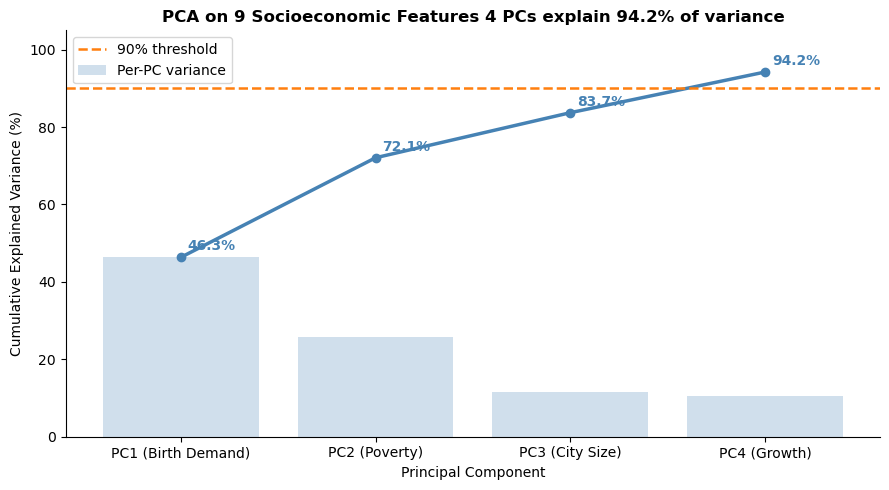

In [10]:
# ── Visualise: cumulative explained variance ──────────────────────────────
fig = plt.figure(figsize=(9, 5))
cum_var = evr.cumsum()
plt.plot(range(1, 5), cum_var * 100, marker='o', lw=2.5, color='steelblue')
plt.bar(range(1, 5), evr * 100, color='steelblue', alpha=0.25, label='Per-PC variance')
plt.axhline(90, color='tab:orange', linestyle='--', lw=1.8, label='90% threshold')
for i, (ev, cv) in enumerate(zip(evr, cum_var), 1):
    plt.annotate(f'{cv*100:.1f}%', (i, cv*100), textcoords='offset points',
                 xytext=(5, 5), fontsize=10, color='steelblue', fontweight='bold')
plt.xticks([1, 2, 3, 4], ['PC1 (Birth Demand)', 'PC2 (Poverty)', 'PC3 (City Size)', 'PC4 (Growth)'])
plt.ylabel('Cumulative Explained Variance (%)')
plt.xlabel('Principal Component')
plt.title('PCA on 9 Socioeconomic Features 4 PCs explain 94.2% of variance', fontweight='bold')
plt.legend()
plt.ylim(0, 105)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


---
## 5. Train / Test Split

In [11]:
print(f"Train: {len(X_train_pca)} LGUs  |  Test: {len(X_test_pca)} LGUs  (75/25 split)")
print()
print(f"{'Tier':<8} {'Train n':>8} {'Train %':>9} {'Test n':>8} {'Test %':>9}")
print("-" * 44)
for t in [0, 1, 2, 3]:
    tr_n = (y_train == t).sum(); tr_p = tr_n / len(y_train) * 100
    te_n = (y_test  == t).sum(); te_p = te_n / len(y_test)  * 100
    print(f"  {t:<6} {tr_n:>8} {tr_p:>8.1f}% {te_n:>8} {te_p:>8.1f}%")
print()
print("All models use X_train_pca / X_test_pca (4 PC scores per LGU).")


Train: 1221 LGUs  |  Test: 408 LGUs  (75/25 split)

Tier      Train n   Train %   Test n    Test %
--------------------------------------------
  0          1003     82.1%      336     82.4%
  1           147     12.0%       49     12.0%
  2            55      4.5%       18      4.4%
  3            16      1.3%        5      1.2%

All models use X_train_pca / X_test_pca (4 PC scores per LGU).


---
## 6. Model 1 — k-Nearest Neighbors Classification

Following **Notebook 1A**: scan `n_neighbors` 1–40 over 20 seeds, plot training and test accuracy with error bars, select optimal `k`.


In [12]:
No_trials = 20

all_training_knn = pd.DataFrame()
all_test_knn     = pd.DataFrame()
n_neighbors_settings = range(1, 41)

for seedN in range(1, No_trials + 1):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    training_accuracy, test_accuracy = [], []
    for k in n_neighbors_settings:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr, y_tr)
        training_accuracy.append(knn.score(X_tr, y_tr))
        test_accuracy.append(knn.score(X_te, y_te))
    all_training_knn[seedN] = training_accuracy
    all_test_knn[seedN]     = test_accuracy

best_k = n_neighbors_settings[np.argmax(all_test_knn.mean(axis=1))]
print(f"Highest Average Test Accuracy = {np.amax(all_test_knn.mean(axis=1)):.4f}")
print(f"Best n_neighbors = {best_k}")


Highest Average Test Accuracy = 0.8232
Best n_neighbors = 31


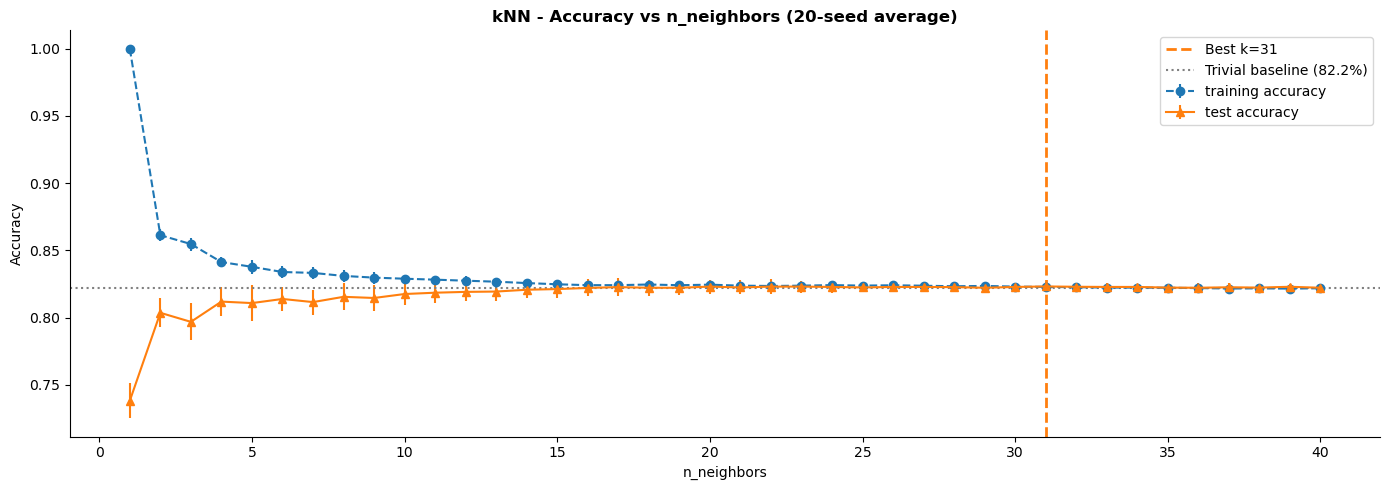

Decision: k=31 where test accuracy peaks before large-k smoothing collapses to majority class.


In [13]:
fig = plt.figure(figsize=(14, 5))
plt.errorbar(n_neighbors_settings, all_training_knn.mean(axis=1),
             yerr=all_training_knn.std(axis=1), label='training accuracy', marker='o', linestyle='dashed')
plt.errorbar(n_neighbors_settings, all_test_knn.mean(axis=1),
             yerr=all_test_knn.std(axis=1), label='test accuracy', marker='^')
plt.axvline(best_k, color='tab:orange', linestyle='--', lw=2, label=f'Best k={best_k}')
plt.axhline(0.822, color='grey', linestyle=':', lw=1.5, label='Trivial baseline (82.2%)')
plt.ylabel('Accuracy')
plt.xlabel('n_neighbors')
plt.title(f'kNN - Accuracy vs n_neighbors ({No_trials}-seed average)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f"Decision: k={best_k} where test accuracy peaks before large-k smoothing collapses to majority class.")


In [14]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_pca, y_train)

knn_train_acc = knn_final.score(X_train_pca, y_train)
knn_test_acc  = knn_final.score(X_test_pca,  y_test)
knn_sweep_acc = all_test_knn.mean(axis=1).max()
knn_sweep_std = all_test_knn.std(axis=1).iloc[np.argmax(all_test_knn.mean(axis=1))]

print(f"kNN (k={best_k})")
print(f"  [Sweep]  Test accuracy: {knn_sweep_acc:.4f} +/- {knn_sweep_std:.4f}")
print(f"  Training set accuracy: {knn_train_acc:.4f}")
print(f"  Test     set accuracy: {knn_test_acc:.4f}")
print()
print(classification_report(y_test, knn_final.predict(X_test_pca),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))


kNN (k=31)
  [Sweep]  Test accuracy: 0.8232 +/- 0.0031
  Training set accuracy: 0.8198
  Test     set accuracy: 0.8260

              precision    recall  f1-score   support

      Tier 0       0.83      1.00      0.91       336
      Tier 1       0.00      0.00      0.00        49
      Tier 2       0.50      0.06      0.10        18
      Tier 3       0.00      0.00      0.00         5

    accuracy                           0.83       408
   macro avg       0.33      0.26      0.25       408
weighted avg       0.70      0.83      0.75       408



---
## 7. Model 2 — Logistic Regression with L2 Regularisation

Following **Notebook 3B**: scan `C` over a log-scale grid using 20 seeds. Higher `C` = less regularisation. `solver='lbfgs'` handles multiclass natively and is fast.


In [15]:
C_settings = [1e-5, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 10000]

all_training_lr2 = pd.DataFrame()
all_test_lr2     = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    training_accuracy, test_accuracy = [], []
    for C in C_settings:
        lr = LogisticRegression(C=C, class_weight='balanced',
                                 solver='lbfgs', max_iter=1000, random_state=42)
        lr.fit(X_tr, y_tr)
        training_accuracy.append(lr.score(X_tr, y_tr))
        test_accuracy.append(lr.score(X_te, y_te))
    all_training_lr2[seedN] = training_accuracy
    all_test_lr2[seedN]     = test_accuracy

best_C_lr2 = C_settings[np.argmax(all_test_lr2.mean(axis=1))]
print(f"Highest Average Test Accuracy = {np.amax(all_test_lr2.mean(axis=1)):.4f}")
print(f"Best C = {best_C_lr2}")


Highest Average Test Accuracy = 0.7877
Best C = 1e-05


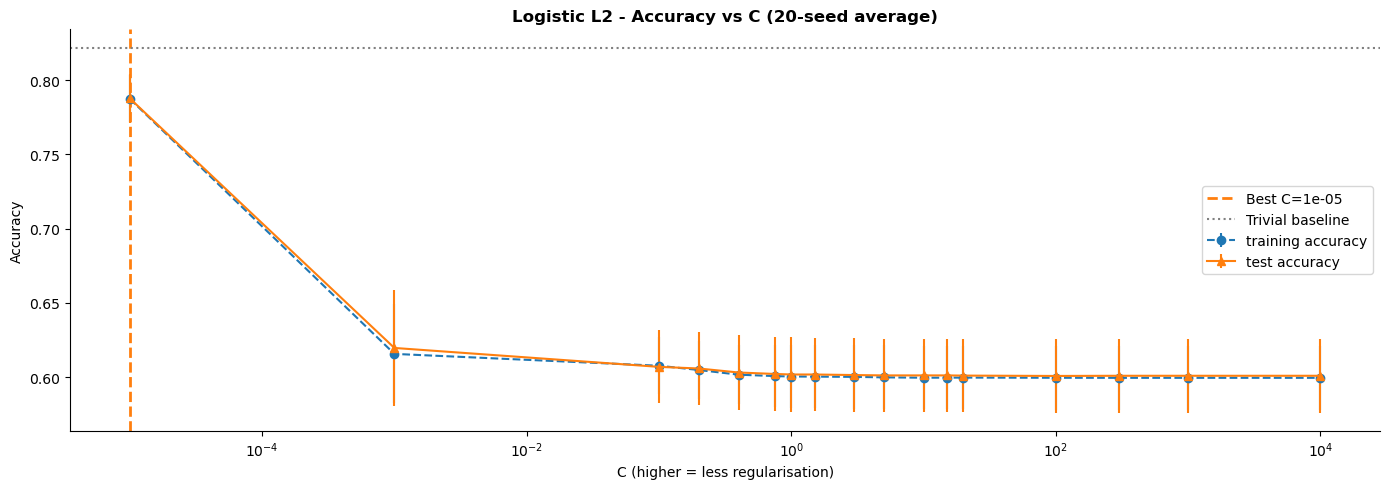

In [16]:
fig = plt.figure(figsize=(14, 5))
plt.xscale('log')
plt.errorbar(C_settings, all_training_lr2.mean(axis=1),
             yerr=all_training_lr2.std(axis=1), label='training accuracy', marker='o', linestyle='dashed')
plt.errorbar(C_settings, all_test_lr2.mean(axis=1),
             yerr=all_test_lr2.std(axis=1), label='test accuracy', marker='^')
plt.axvline(best_C_lr2, color='tab:orange', linestyle='--', lw=2, label=f'Best C={best_C_lr2}')
plt.axhline(0.822, color='grey', linestyle=':', lw=1.5, label='Trivial baseline')
plt.ylabel('Accuracy')
plt.xlabel('C (higher = less regularisation)')
plt.title(f'Logistic L2 - Accuracy vs C ({No_trials}-seed average)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


Logistic L2 (C=1e-05)
  [Sweep]  Test accuracy: 0.7877 +/- 0.0162
  Training set accuracy: 0.8059
  Test     set accuracy: 0.8162


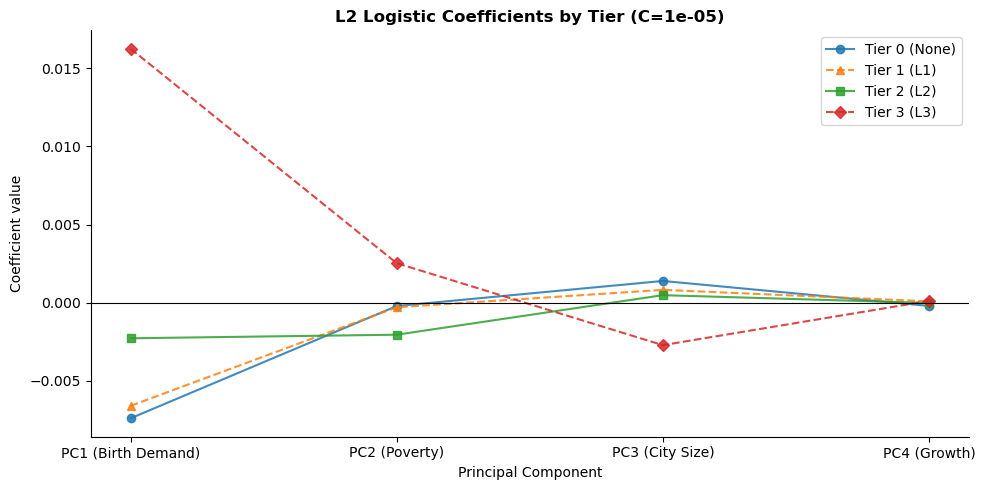

Positive coefficient: higher PC score associated with predicting that tier.
Negative coefficient: higher PC score predicts against that tier.


In [17]:
lr2_final = LogisticRegression(C=best_C_lr2, class_weight='balanced',
                                solver='lbfgs', max_iter=1000, random_state=42)
lr2_final.fit(X_train_pca, y_train)

lr2_train_acc = lr2_final.score(X_train_pca, y_train)
lr2_test_acc  = lr2_final.score(X_test_pca,  y_test)
lr2_sweep_acc = all_test_lr2.mean(axis=1).max()
lr2_sweep_std = all_test_lr2.std(axis=1).iloc[np.argmax(all_test_lr2.mean(axis=1))]

print(f"Logistic L2 (C={best_C_lr2})")
print(f"  [Sweep]  Test accuracy: {lr2_sweep_acc:.4f} +/- {lr2_sweep_std:.4f}")
print(f"  Training set accuracy: {lr2_train_acc:.4f}")
print(f"  Test     set accuracy: {lr2_test_acc:.4f}")

# Coefficient plot: one line per tier (Notebook 3B style, applied to 4 PCs)
pc_names = ['PC1 (Birth Demand)', 'PC2 (Poverty)', 'PC3 (City Size)', 'PC4 (Growth)']
fig = plt.figure(figsize=(10, 5))
markers = ['-o', '--^', '-s', '--D']
tier_names = ['Tier 0 (None)', 'Tier 1 (L1)', 'Tier 2 (L2)', 'Tier 3 (L3)']
for i, (name, marker) in enumerate(zip(tier_names, markers)):
    plt.plot(lr2_final.coef_[i], marker, label=name, alpha=0.85)
plt.xticks(range(4), pc_names)
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Principal Component')
plt.ylabel('Coefficient value')
plt.title(f'L2 Logistic Coefficients by Tier (C={best_C_lr2})', fontweight='bold')
plt.legend(fontsize=10)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print("Positive coefficient: higher PC score associated with predicting that tier.")
print("Negative coefficient: higher PC score predicts against that tier.")


---
## 8. Model 3 — Logistic Regression with L1 Regularisation



In [18]:
all_training_lr1 = pd.DataFrame()
all_test_lr1     = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    training_accuracy, test_accuracy = [], []
    for C in C_settings:
        lr = OneVsRestClassifier(
            LogisticRegression(C=C, penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced')
        )
        lr.fit(X_tr, y_tr)
        training_accuracy.append(lr.score(X_tr, y_tr))
        test_accuracy.append(lr.score(X_te, y_te))
    all_training_lr1[seedN] = training_accuracy
    all_test_lr1[seedN]     = test_accuracy

best_C_lr1 = C_settings[np.argmax(all_test_lr1.mean(axis=1))]
print(f"Highest Average Test Accuracy = {np.amax(all_test_lr1.mean(axis=1)):.4f}")
print(f"Best C = {best_C_lr1}")


Highest Average Test Accuracy = 0.6398
Best C = 10


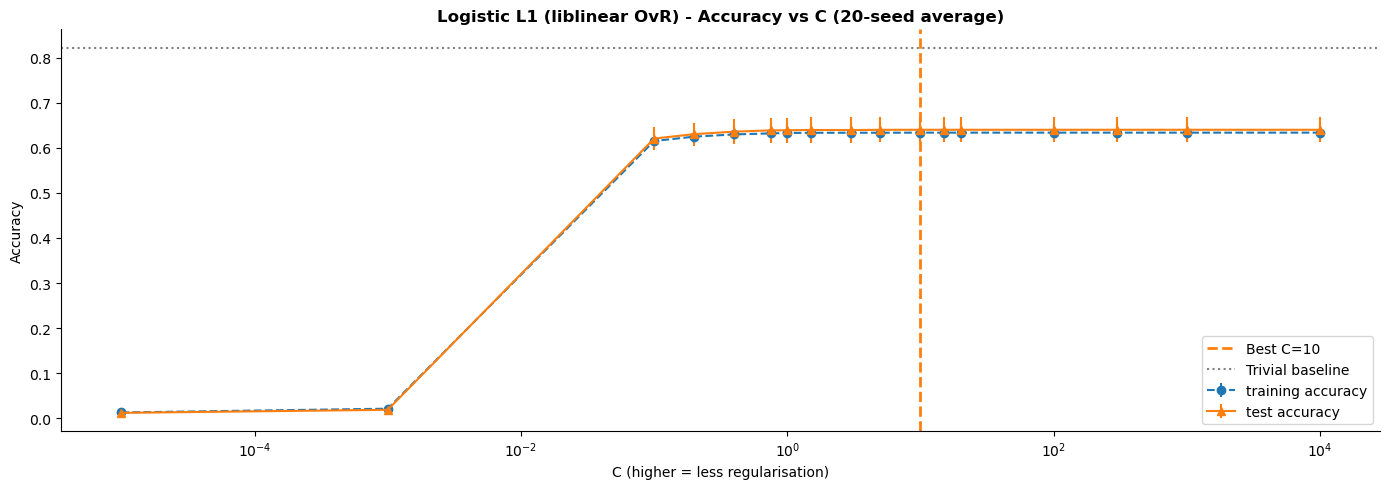

In [19]:
fig = plt.figure(figsize=(14, 5))
plt.xscale('log')
plt.errorbar(C_settings, all_training_lr1.mean(axis=1),
             yerr=all_training_lr1.std(axis=1), label='training accuracy', marker='o', linestyle='dashed')
plt.errorbar(C_settings, all_test_lr1.mean(axis=1),
             yerr=all_test_lr1.std(axis=1), label='test accuracy', marker='^')
plt.axvline(best_C_lr1, color='tab:orange', linestyle='--', lw=2, label=f'Best C={best_C_lr1}')
plt.axhline(0.822, color='grey', linestyle=':', lw=1.5, label='Trivial baseline')
plt.ylabel('Accuracy')
plt.xlabel('C (higher = less regularisation)')
plt.title(f'Logistic L1 (liblinear OvR) - Accuracy vs C ({No_trials}-seed average)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


Logistic L1 (C=10, liblinear OvR)
  [Sweep]  Test accuracy: 0.6398 +/- 0.0277
  Training set accuracy: 0.6691
  Test     set accuracy: 0.6422

PC coefficients per tier (0 = excluded by L1 sparsity):
               PC1 (Birth Demand)  PC2 (Poverty)  PC3 (City Size)  PC4 (Growth)
Tier 0 (None)              -0.723         -0.128            0.655        -0.044
Tier 1 (L1)                -0.014         -0.046           -0.450         0.074
Tier 2 (L2)                 0.633         -0.302           -0.351        -0.133
Tier 3 (L3)                 1.382         -0.278           -0.727         0.971

Total coefficients zeroed out: 0/16


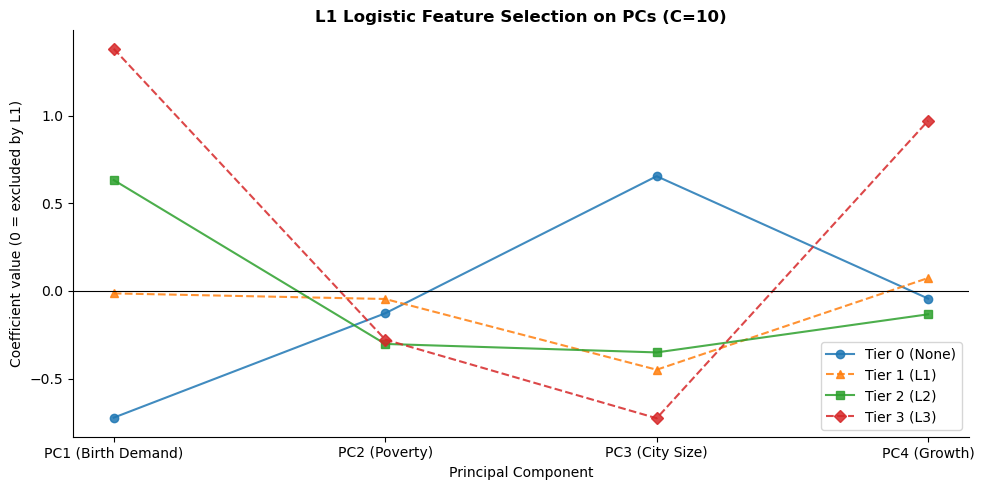

PCs with zero coefficients were excluded as uninformative by L1 regularisation.


In [20]:
lr1_final = OneVsRestClassifier(
    LogisticRegression(C=best_C_lr1, penalty='l1', solver='liblinear',
                       max_iter=1000, class_weight='balanced')
)
lr1_final.fit(X_train_pca, y_train)

lr1_train_acc = lr1_final.score(X_train_pca, y_train)
lr1_test_acc  = lr1_final.score(X_test_pca,  y_test)
lr1_sweep_acc = all_test_lr1.mean(axis=1).max()
lr1_sweep_std = all_test_lr1.std(axis=1).iloc[np.argmax(all_test_lr1.mean(axis=1))]

all_coefs = np.array([est.coef_[0] for est in lr1_final.estimators_])  # (4 tiers, 4 PCs)

print(f"Logistic L1 (C={best_C_lr1}, liblinear OvR)")
print(f"  [Sweep]  Test accuracy: {lr1_sweep_acc:.4f} +/- {lr1_sweep_std:.4f}")
print(f"  Training set accuracy: {lr1_train_acc:.4f}")
print(f"  Test     set accuracy: {lr1_test_acc:.4f}")
print()
print("PC coefficients per tier (0 = excluded by L1 sparsity):")
coef_df = pd.DataFrame(all_coefs, index=tier_names, columns=pc_names)
print(coef_df.round(3).to_string())
print()
zeroed = (all_coefs == 0).sum()
print(f"Total coefficients zeroed out: {zeroed}/{all_coefs.size}")

# Coefficient plot (Notebook 3B style)
fig = plt.figure(figsize=(10, 5))
for i, (name, marker) in enumerate(zip(tier_names, markers)):
    plt.plot(all_coefs[i], marker, label=name, alpha=0.85)
plt.xticks(range(4), pc_names)
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Principal Component')
plt.ylabel('Coefficient value (0 = excluded by L1)')
plt.title(f'L1 Logistic Feature Selection on PCs (C={best_C_lr1})', fontweight='bold')
plt.legend(fontsize=10)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print("PCs with zero coefficients were excluded as uninformative by L1 regularisation.")


---
## 9. Model 4 — Random Forest Classifier

Following **Notebook 4A**: scan `max_depth` over 20 seeds. Scale-invariant — PC scores are used directly. Produces feature importances showing which of the 4 named components matter most.


In [21]:
all_training_rf = pd.DataFrame()
all_test_rf     = pd.DataFrame()
maxdepth_settings = range(1, 21)

for seedN in range(1, No_trials + 1):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    training_accuracy, test_accuracy = [], []
    for depth in maxdepth_settings:
        rf = RandomForestClassifier(n_estimators=100, max_depth=depth,
                                     class_weight='balanced', random_state=0, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        training_accuracy.append(rf.score(X_tr, y_tr))
        test_accuracy.append(rf.score(X_te, y_te))
    all_training_rf[seedN] = training_accuracy
    all_test_rf[seedN]     = test_accuracy

best_depth_rf = maxdepth_settings[np.argmax(all_test_rf.mean(axis=1))]
print(f"Highest Average Test Accuracy = {np.amax(all_test_rf.mean(axis=1)):.4f}")
print(f"Best max_depth = {best_depth_rf}")


Highest Average Test Accuracy = 0.8183
Best max_depth = 19


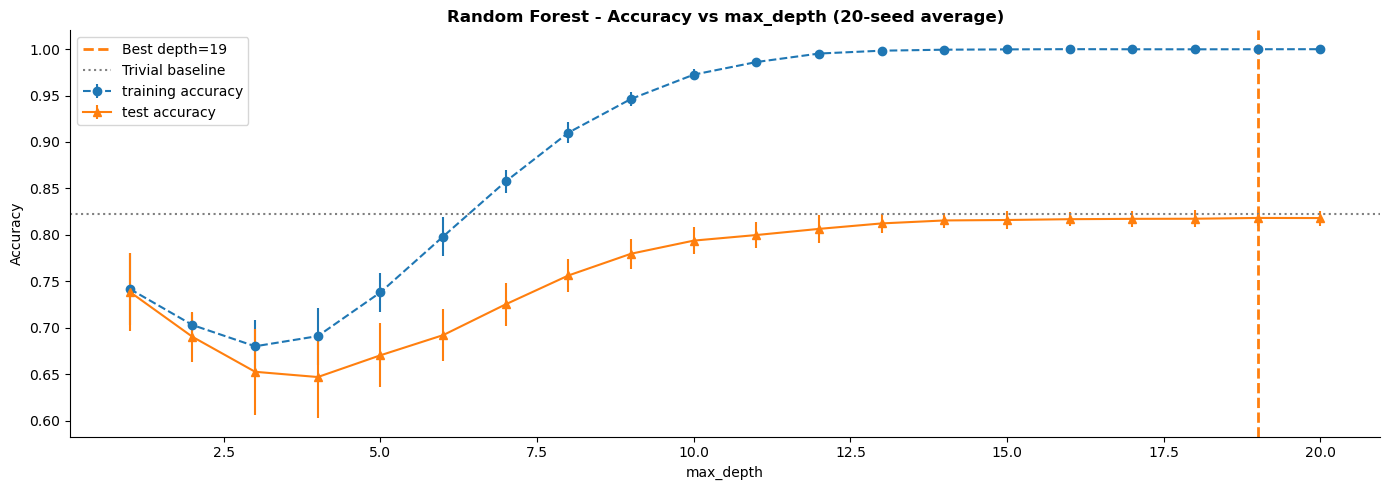

Decision: depth=19. Deeper trees overfit (training keeps rising).


In [22]:
fig = plt.figure(figsize=(14, 5))
plt.errorbar(maxdepth_settings, all_training_rf.mean(axis=1),
             yerr=all_training_rf.std(axis=1), label='training accuracy', marker='o', linestyle='dashed')
plt.errorbar(maxdepth_settings, all_test_rf.mean(axis=1),
             yerr=all_test_rf.std(axis=1), label='test accuracy', marker='^')
plt.axvline(best_depth_rf, color='tab:orange', linestyle='--', lw=2, label=f'Best depth={best_depth_rf}')
plt.axhline(0.822, color='grey', linestyle=':', lw=1.5, label='Trivial baseline')
plt.ylabel('Accuracy')
plt.xlabel('max_depth')
plt.title(f'Random Forest - Accuracy vs max_depth ({No_trials}-seed average)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f"Decision: depth={best_depth_rf}. Deeper trees overfit (training keeps rising).")


Random Forest (depth=19, 300 trees)
  [Sweep]  Test accuracy: 0.8183 +/- 0.0089
  Training set accuracy: 1.0000
  Test     set accuracy: 0.8137


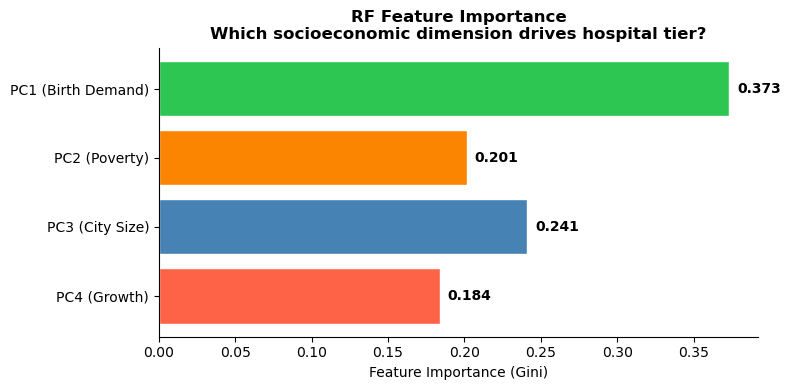

The most important PC tells you which socioeconomic dimension drives tier prediction.


In [23]:
rf_final = RandomForestClassifier(n_estimators=300, max_depth=best_depth_rf,
                                   class_weight='balanced', random_state=0, n_jobs=-1)
rf_final.fit(X_train_pca, y_train)

rf_train_acc = rf_final.score(X_train_pca, y_train)
rf_test_acc  = rf_final.score(X_test_pca,  y_test)
rf_sweep_acc = all_test_rf.mean(axis=1).max()
rf_sweep_std = all_test_rf.std(axis=1).iloc[np.argmax(all_test_rf.mean(axis=1))]

print(f"Random Forest (depth={best_depth_rf}, 300 trees)")
print(f"  [Sweep]  Test accuracy: {rf_sweep_acc:.4f} +/- {rf_sweep_std:.4f}")
print(f"  Training set accuracy: {rf_train_acc:.4f}")
print(f"  Test     set accuracy: {rf_test_acc:.4f}")

# Feature importance — now directly labelled with PC names
fi = rf_final.feature_importances_
fig = plt.figure(figsize=(8, 4))
bars = plt.barh(pc_names[::-1], fi[::-1], color=['#2dc653','#fb8500','steelblue','tomato'][::-1],
                edgecolor='white')
for bar, val in zip(bars, fi[::-1]):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
plt.xlabel('Feature Importance (Gini)')
plt.title(f'RF Feature Importance\nWhich socioeconomic dimension drives hospital tier?', fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print("The most important PC tells you which socioeconomic dimension drives tier prediction.")


---
## 10. Model 5 — Gradient Boosted Trees

Following **Notebook 4A**: GBM with `n_estimators=100`, `max_depth=3`, `learning_rate=0.1` by default. We scan `max_depth` over 20 seeds to tune, then display feature importances on the named PCs.


In [24]:
all_training_gbm = pd.DataFrame()
all_test_gbm     = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all_pca, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    training_accuracy, test_accuracy = [], []
    for depth in maxdepth_settings:
        gbm = GradientBoostingClassifier(n_estimators=100, max_depth=depth,
                                          learning_rate=0.1, random_state=0)
        gbm.fit(X_tr, y_tr)
        training_accuracy.append(gbm.score(X_tr, y_tr))
        test_accuracy.append(gbm.score(X_te, y_te))
    all_training_gbm[seedN] = training_accuracy
    all_test_gbm[seedN]     = test_accuracy

best_depth_gbm = maxdepth_settings[np.argmax(all_test_gbm.mean(axis=1))]
print(f"Highest Average Test Accuracy = {np.amax(all_test_gbm.mean(axis=1)):.4f}")
print(f"Best max_depth = {best_depth_gbm}")


Highest Average Test Accuracy = 0.8234
Best max_depth = 1


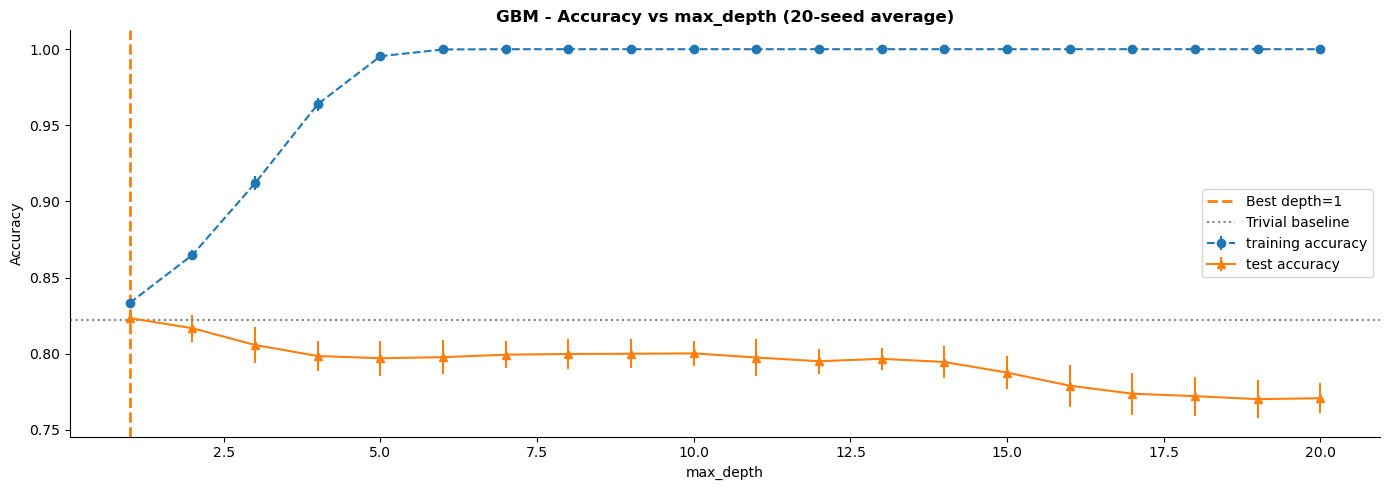

In [25]:
fig = plt.figure(figsize=(14, 5))
plt.errorbar(maxdepth_settings, all_training_gbm.mean(axis=1),
             yerr=all_training_gbm.std(axis=1), label='training accuracy', marker='o', linestyle='dashed')
plt.errorbar(maxdepth_settings, all_test_gbm.mean(axis=1),
             yerr=all_test_gbm.std(axis=1), label='test accuracy', marker='^')
plt.axvline(best_depth_gbm, color='tab:orange', linestyle='--', lw=2, label=f'Best depth={best_depth_gbm}')
plt.axhline(0.822, color='grey', linestyle=':', lw=1.5, label='Trivial baseline')
plt.ylabel('Accuracy')
plt.xlabel('max_depth')
plt.title(f'GBM - Accuracy vs max_depth ({No_trials}-seed average)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


GBM (depth=1, 200 trees, lr=0.1)
  [Sweep]  Test accuracy: 0.8234 +/- 0.0046
  Training set accuracy: 0.8395
  Test     set accuracy: 0.8211


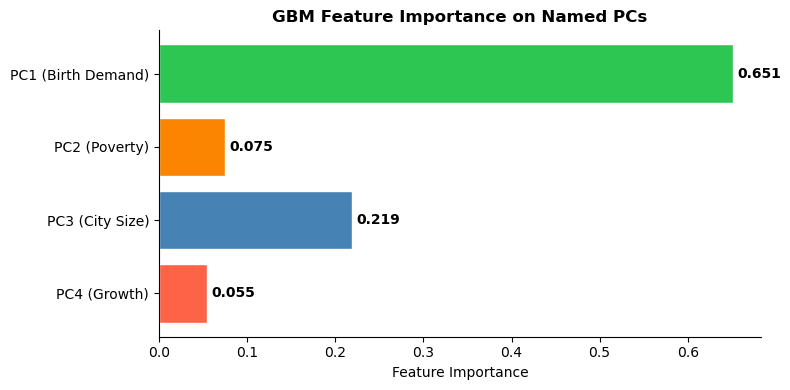

In [26]:
gbm_final = GradientBoostingClassifier(n_estimators=200, max_depth=best_depth_gbm,
                                        learning_rate=0.1, random_state=0)
gbm_final.fit(X_train_pca, y_train)

gbm_train_acc = gbm_final.score(X_train_pca, y_train)
gbm_test_acc  = gbm_final.score(X_test_pca,  y_test)
gbm_sweep_acc = all_test_gbm.mean(axis=1).max()
gbm_sweep_std = all_test_gbm.std(axis=1).iloc[np.argmax(all_test_gbm.mean(axis=1))]

print(f"GBM (depth={best_depth_gbm}, 200 trees, lr=0.1)")
print(f"  [Sweep]  Test accuracy: {gbm_sweep_acc:.4f} +/- {gbm_sweep_std:.4f}")
print(f"  Training set accuracy: {gbm_train_acc:.4f}")
print(f"  Test     set accuracy: {gbm_test_acc:.4f}")

fi_gbm = gbm_final.feature_importances_
fig = plt.figure(figsize=(8, 4))
bars = plt.barh(pc_names[::-1], fi_gbm[::-1], color=['#2dc653','#fb8500','steelblue','tomato'][::-1],
                edgecolor='white')
for bar, val in zip(bars, fi_gbm[::-1]):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
plt.xlabel('Feature Importance')
plt.title(f'GBM Feature Importance on Named PCs', fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


---
## 11. Model Comparison

In [27]:
model_names = [f'kNN (k={best_k})', f'Logistic L2 (C={best_C_lr2})',
               f'Logistic L1 (C={best_C_lr1})', f'RF (d={best_depth_rf})',
               f'GBM (d={best_depth_gbm})']
sweep_accs  = [knn_sweep_acc, lr2_sweep_acc, lr1_sweep_acc, rf_sweep_acc,  gbm_sweep_acc]
sweep_stds  = [knn_sweep_std, lr2_sweep_std, lr1_sweep_std, rf_sweep_std,  gbm_sweep_std]
train_accs  = [knn_train_acc, lr2_train_acc, lr1_train_acc, rf_train_acc,  gbm_train_acc]
test_accs   = [knn_test_acc,  lr2_test_acc,  lr1_test_acc,  rf_test_acc,   gbm_test_acc]

results = pd.DataFrame({
    'Model':            model_names,
    'Sweep Acc (mean)': sweep_accs,
    'Sweep Acc (std)':  sweep_stds,
    'Train Acc':        train_accs,
    'Test Acc':         test_accs,
    'Input':            ['4 PCs'] * 5,
}).set_index('Model').round(4)

print("All models use 4 PCA components from 9 socioeconomic features.")
print()
print(results.to_string())
print()
print(f"Best model: {results['Sweep Acc (mean)'].idxmax()}")


All models use 4 PCA components from 9 socioeconomic features.

                       Sweep Acc (mean)  Sweep Acc (std)  Train Acc  Test Acc  Input
Model                                                                               
kNN (k=31)                       0.8232           0.0031     0.8198    0.8260  4 PCs
Logistic L2 (C=1e-05)            0.7877           0.0162     0.8059    0.8162  4 PCs
Logistic L1 (C=10)               0.6398           0.0277     0.6691    0.6422  4 PCs
RF (d=19)                        0.8183           0.0089     1.0000    0.8137  4 PCs
GBM (d=1)                        0.8234           0.0046     0.8395    0.8211  4 PCs

Best model: GBM (d=1)


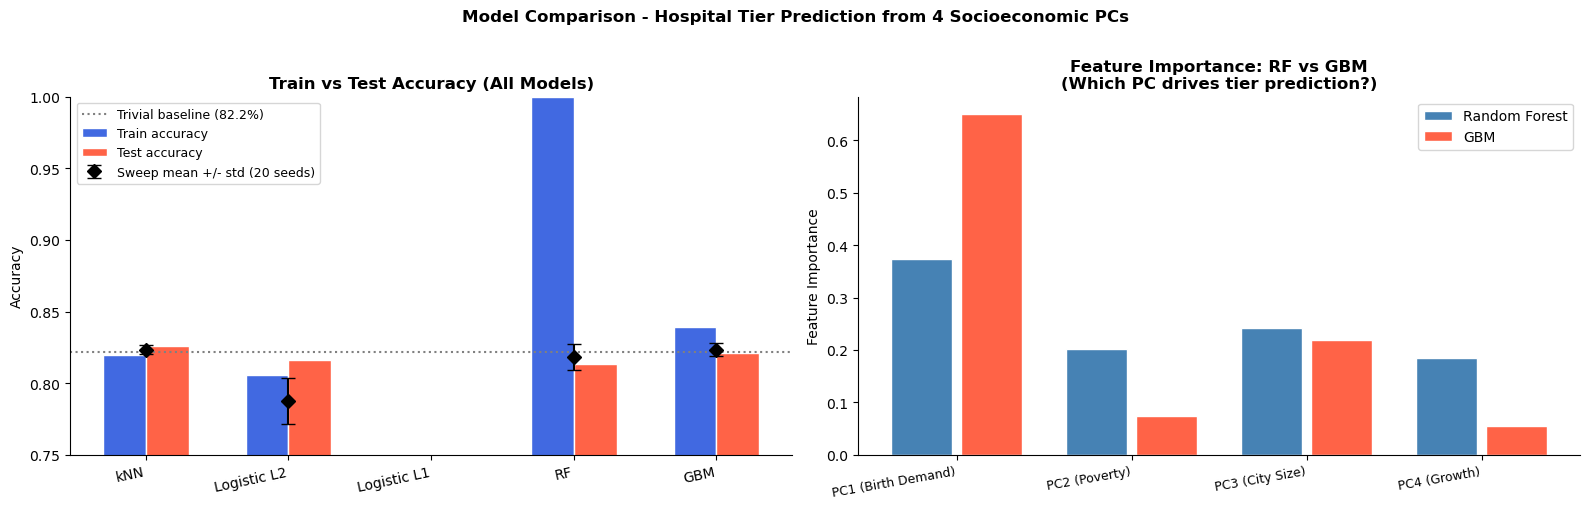

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(results))
w = 0.30
axes[0].bar(x - w/2, results['Train Acc'], w, label='Train accuracy', color='royalblue', edgecolor='white')
axes[0].bar(x + w/2, results['Test Acc'],  w, label='Test accuracy',  color='tomato',    edgecolor='white')
axes[0].errorbar(x, results['Sweep Acc (mean)'], yerr=results['Sweep Acc (std)'],
                 fmt='D', color='black', markersize=7, capsize=5, label=f'Sweep mean +/- std ({No_trials} seeds)')
axes[0].axhline(0.822, color='grey', linestyle=':', lw=1.5, label='Trivial baseline (82.2%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.split('(')[0].strip() for m in results.index], rotation=12, ha='right', fontsize=10)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy (All Models)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.75, 1.0)
axes[0].spines[['top', 'right']].set_visible(False)

# Feature importance comparison on named PCs
fi_rf_arr  = rf_final.feature_importances_
fi_gbm_arr = gbm_final.feature_importances_
xi = np.arange(4)
axes[1].bar(xi - 0.2, fi_rf_arr,  0.35, label='Random Forest', color='steelblue', edgecolor='white')
axes[1].bar(xi + 0.2, fi_gbm_arr, 0.35, label='GBM',           color='tomato',    edgecolor='white')
axes[1].set_xticks(xi); axes[1].set_xticklabels(pc_names, rotation=10, ha='right', fontsize=9)
axes[1].set_ylabel('Feature Importance')
axes[1].set_title('Feature Importance: RF vs GBM\n(Which PC drives tier prediction?)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Model Comparison - Hospital Tier Prediction from 4 Socioeconomic PCs',
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


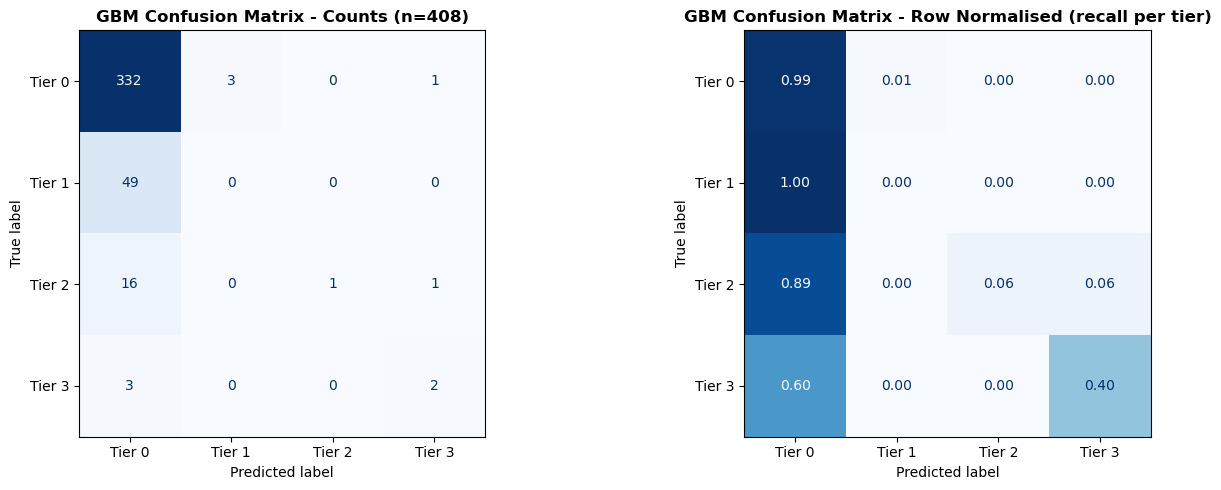

              precision    recall  f1-score   support

      Tier 0       0.83      0.99      0.90       336
      Tier 1       0.00      0.00      0.00        49
      Tier 2       1.00      0.06      0.11        18
      Tier 3       0.50      0.40      0.44         5

    accuracy                           0.82       408
   macro avg       0.58      0.36      0.36       408
weighted avg       0.73      0.82      0.75       408



In [29]:
# Best model confusion matrix
y_pred_best = gbm_final.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['Tier 0','Tier 1','Tier 2','Tier 3']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'GBM Confusion Matrix - Counts (n={len(y_test)})', fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Tier 0','Tier 1','Tier 2','Tier 3']).plot(
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title('GBM Confusion Matrix - Row Normalised (recall per tier)', fontweight='bold')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred_best,
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))


---
## 12. Underserved LGU Identification

In [30]:
pred_full  = gbm_final.predict(X_all_pca)
proba_full = gbm_final.predict_proba(X_all_pca)

model_df = model_df.copy().reset_index(drop=True)
model_df['pred_tier']     = pred_full
model_df['tier_gap']      = model_df['pred_tier'] - model_df['tier']
model_df['expected_tier'] = (proba_full * np.array([0, 1, 2, 3])).sum(axis=1)

print("Tier gap (predicted - actual) distribution:")
print(model_df['tier_gap'].value_counts().sort_index())
print()

underserved  = model_df[model_df['tier_gap'] > 0].sort_values('expected_tier', ascending=False)
appropriate  = model_df[model_df['tier_gap'] == 0]
oversupplied = model_df[model_df['tier_gap'] < 0]

print(f"Underserved  (pred > actual): {len(underserved):>4} LGUs  <- priority for new hospitals")
print(f"Appropriate  (pred = actual): {len(appropriate):>4} LGUs")
print(f"Oversupplied (pred < actual): {len(oversupplied):>4} LGUs")


Tier gap (predicted - actual) distribution:
tier_gap
-3      10
-2      62
-1     189
 0    1360
 1       7
 3       1
Name: count, dtype: int64

Underserved  (pred > actual):    8 LGUs  <- priority for new hospitals
Appropriate  (pred = actual): 1360 LGUs
Oversupplied (pred < actual):  261 LGUs


In [31]:
us = underserved[['city_municipality', 'region', 'tier', 'pred_tier',
                   'tier_gap', 'expected_tier', 'poverty_incidence_2023_pct']].copy()
us.columns = ['LGU', 'Region', 'Actual', 'Predicted', 'Gap', 'Exp. Tier', 'Poverty 2023 (%)']
us['Exp. Tier'] = us['Exp. Tier'].round(3)
us['Poverty 2023 (%)'] = us['Poverty 2023 (%)'].round(1)
print("UNDERSERVED LGUs (predicted tier > actual, sorted by Expected Tier):")
print(us.to_string(index=False))


UNDERSERVED LGUs (predicted tier > actual, sorted by Expected Tier):
           LGU                                 Region  Actual  Predicted  Gap  Exp. Tier  Poverty 2023 (%)
CITY OF MANILA          NATIONAL CAPITAL REGION (NCR)       0          3    3      2.979               0.7
  CITY OF IMUS               REGION IV-A (CALABARZON)       2          3    1      1.980               4.6
       MARILAO             REGION III (CENTRAL LUZON)       1          2    1      1.277               8.3
 CITY OF BINAN               REGION IV-A (CALABARZON)       0          1    1      0.992               4.4
CITY OF CARCAR           REGION VII (CENTRAL VISAYAS)       0          1    1      0.874              21.6
 CITY OF CADIZ             NEGROS ISLAND REGION (NIR)       0          1    1      0.809              23.7
         BULAN                REGION V (BICOL REGION)       0          1    1      0.682              36.1
       TANUDAN CORDILLERA ADMINISTRATIVE REGION (CAR)       0          1   

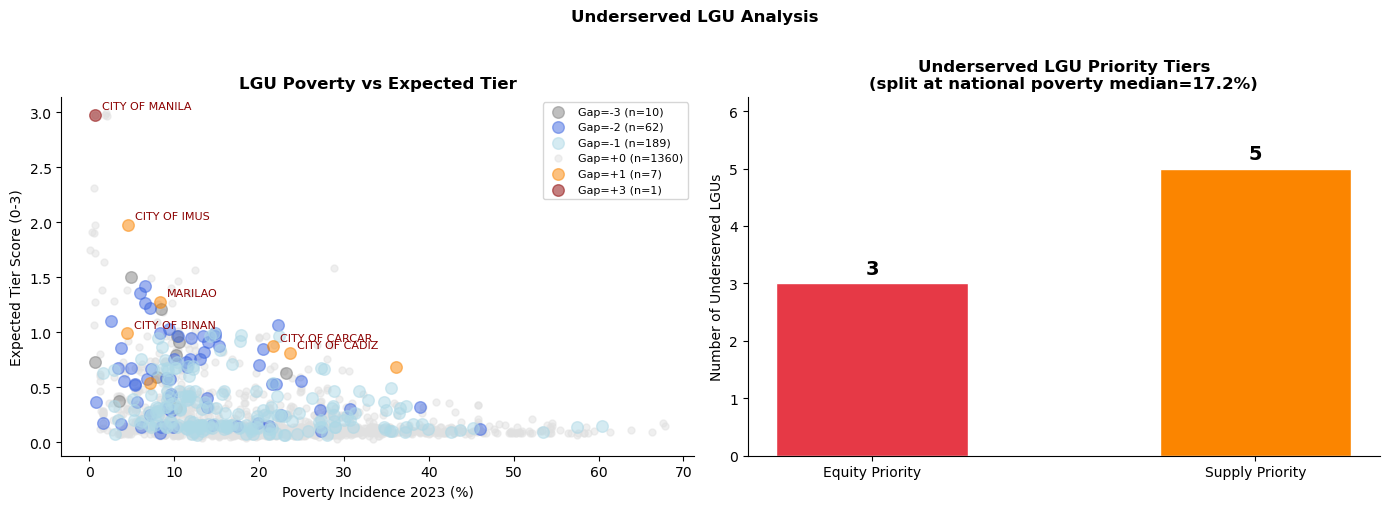

Equity priority (underserved + poverty > 17.2%): 3 LGUs
Supply priority (underserved + poverty <= 17.2%): 5 LGUs


In [32]:
# Poverty stratification among underserved
pov_median = model_df['poverty_incidence_2023_pct'].median()
eq_prio  = underserved[underserved['poverty_incidence_2023_pct'] >  pov_median]
sup_prio = underserved[underserved['poverty_incidence_2023_pct'] <= pov_median]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gap_colors = {-2:'royalblue', -1:'lightblue', 0:'#e0e0e0', 1:'#fb8500', 2:'tomato', 3:'darkred'}
for gap_val, subset in model_df.groupby('tier_gap'):
    axes[0].scatter(subset['poverty_incidence_2023_pct'], subset['expected_tier'],
                    color=gap_colors.get(gap_val, 'grey'), alpha=0.5,
                    s=25 if gap_val == 0 else 70,
                    label=f'Gap={gap_val:+d} (n={len(subset)})',
                    zorder=3 if abs(gap_val) > 0 else 1)
for _, row in underserved.head(6).iterrows():
    axes[0].annotate(row['city_municipality'],
                     (row['poverty_incidence_2023_pct'], row['expected_tier']),
                     fontsize=8, xytext=(5, 4), textcoords='offset points', color='darkred')
axes[0].set_xlabel('Poverty Incidence 2023 (%)')
axes[0].set_ylabel('Expected Tier Score (0-3)')
axes[0].set_title('LGU Poverty vs Expected Tier', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].spines[['top', 'right']].set_visible(False)

cat_labels = ['Equity Priority', 'Supply Priority']
cat_counts = [len(eq_prio), len(sup_prio)]
cat_colors = ['#e63946', '#fb8500']
bars2 = axes[1].bar(cat_labels, cat_counts, color=cat_colors, edgecolor='white', width=0.5)
for bar, cnt in zip(bars2, cat_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(cnt), ha='center', va='bottom', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Underserved LGUs')
axes[1].set_title(f'Underserved LGU Priority Tiers\n(split at national poverty median={pov_median:.1f}%)',
                   fontweight='bold')
axes[1].set_ylim(0, max(cat_counts) * 1.25)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Underserved LGU Analysis', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f"Equity priority (underserved + poverty > {pov_median:.1f}%): {len(eq_prio)} LGUs")
print(f"Supply priority (underserved + poverty <= {pov_median:.1f}%): {len(sup_prio)} LGUs")


---
## 13. Novelty — Expected Tier and PC2 Poverty Equity Analysis

### Expected Tier as a Continuous Underservice Score

The model produces four probabilities per LGU: P(Tier 0), P(Tier 1), P(Tier 2), P(Tier 3). These sum to 1. The **Expected Tier** is their weighted average:

$$E[tier] = P(T=0) \times 0 + P(T=1) \times 1 + P(T=2) \times 2 + P(T=3) \times 3$$

This converts a discrete 4-class prediction into a **continuous priority score**. Among underserved LGUs, those with higher expected tier are more urgently underserved. Not achievable with three separate binary classifiers.

### PC2 (Poverty) as Equity Lens

PC2 is the pure poverty axis. A higher PC2 score = higher poverty incidence. We can now ask: across all LGUs, does a higher poverty axis score predict a *lower* tier? If yes, that is the equity finding — poverty suppresses hospital tier independently of birth demand, city size, and growth.


In [33]:
# PC2 scores for all LGUs
pc2_scores = X_all_pca[:, 1]   # 0-indexed: PC2 is column index 1

print("PC2 (Poverty axis) score by actual tier:")
for t in [0, 1, 2, 3]:
    mask = (y_all == t).values
    med  = np.median(pc2_scores[mask])
    mn   = pc2_scores[mask].mean()
    print(f"  Tier {t} ({labels[t]:<22}): median PC2 = {med:+.3f},  mean PC2 = {mn:+.3f}")

print()
print("Interpretation:")
print("  Positive PC2 = higher poverty. Negative PC2 = lower poverty.")
print("  If higher tiers show lower PC2 scores, poverty suppresses tier.")


PC2 (Poverty axis) score by actual tier:
  Tier 0 (No hospital           ): median PC2 = -0.199,  mean PC2 = +0.051
  Tier 1 (Level 1 (primary)     ): median PC2 = -0.396,  mean PC2 = -0.149
  Tier 2 (Level 2 (secondary)   ): median PC2 = -0.683,  mean PC2 = -0.506
  Tier 3 (Level 3 (tertiary)    ): median PC2 = -0.337,  mean PC2 = +0.822

Interpretation:
  Positive PC2 = higher poverty. Negative PC2 = lower poverty.
  If higher tiers show lower PC2 scores, poverty suppresses tier.


In [34]:
# Statistical tests
pov_raw = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].dropna().values for t in range(4)]
stat_kw, p_kw = stats.kruskal(*pov_raw)
stat_mw, p_mw = stats.mannwhitneyu(pov_raw[0], pov_raw[3], alternative='greater')

print(f"Kruskal-Wallis (poverty differs across tiers): H={stat_kw:.1f}, p={p_kw:.2e}")
print(f"Mann-Whitney (Tier 0 poverty > Tier 3 poverty): p={p_mw:.2e}")
print()
print("Poverty incidence 2023 by tier:")
for t, vals in enumerate(pov_raw):
    print(f"  Tier {t}: mean={vals.mean():.1f}%  median={np.median(vals):.1f}%")


Kruskal-Wallis (poverty differs across tiers): H=77.5, p=1.04e-16
Mann-Whitney (Tier 0 poverty > Tier 3 poverty): p=2.36e-09

Poverty incidence 2023 by tier:
  Tier 0: mean=20.7%  median=18.5%
  Tier 1: mean=18.4%  median=15.6%
  Tier 2: mean=12.2%  median=9.7%
  Tier 3: mean=6.1%  median=2.1%


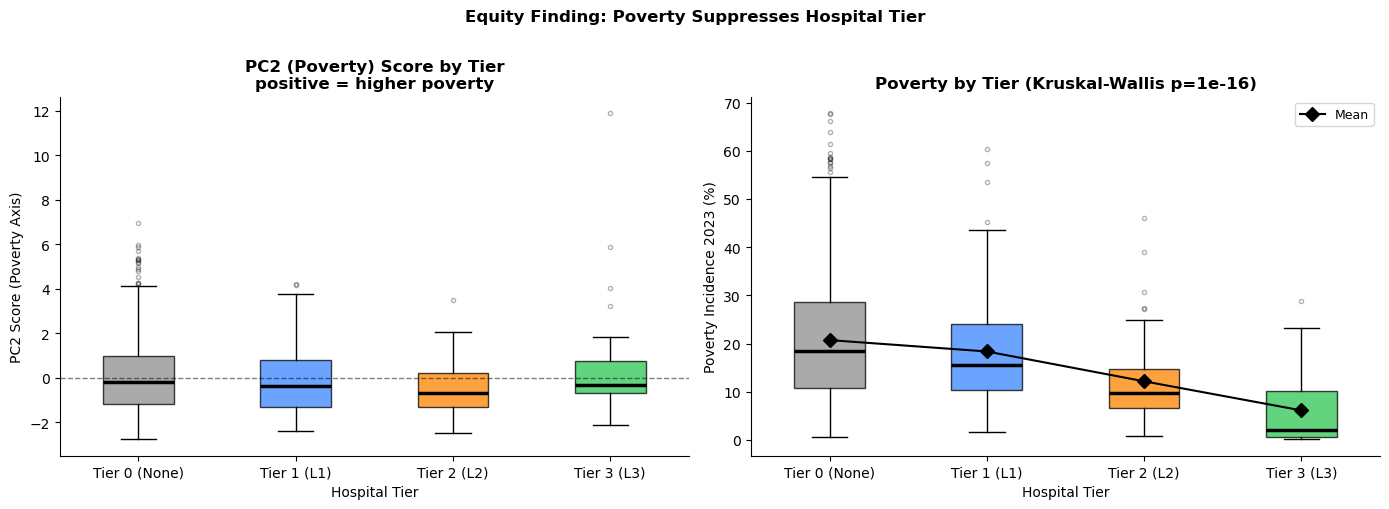

Both panels confirm the equity finding.
Higher-tier hospitals are concentrated in lower-poverty LGUs.


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PC2 (poverty axis) by tier — the equity finding via PCA scores
pc2_by_tier = [pc2_scores[(y_all == t).values] for t in range(4)]
bp = axes[0].boxplot(pc2_by_tier, labels=TIER_LBLS, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch, c in zip(bp['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[0].axhline(0, color='black', linestyle='--', lw=1, alpha=0.5)
axes[0].set_ylabel('PC2 Score (Poverty Axis)')
axes[0].set_xlabel('Hospital Tier')
axes[0].set_title('PC2 (Poverty) Score by Tier\npositive = higher poverty', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Right: raw poverty by tier  
bp2 = axes[1].boxplot(pov_raw, labels=TIER_LBLS, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2.5),
                       flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch, c in zip(bp2['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.75)
means = [v.mean() for v in pov_raw]
axes[1].plot(range(1,5), means, 'D-', color='black', ms=7, zorder=5, label='Mean')
axes[1].set_ylabel('Poverty Incidence 2023 (%)')
axes[1].set_xlabel('Hospital Tier')
axes[1].set_title(f'Poverty by Tier (Kruskal-Wallis p={p_kw:.0e})', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Equity Finding: Poverty Suppresses Hospital Tier', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print("Both panels confirm the equity finding.")
print("Higher-tier hospitals are concentrated in lower-poverty LGUs.")


---
## 14. Conclusion

In [36]:
print("=" * 68)
print("FINAL MODEL SUMMARY")
print("=" * 68)
print()
print("Input:  4 PCA components from 9 socioeconomic features")
print("        PC1=Birth Demand, PC2=Poverty, PC3=City Size, PC4=Growth")
print("Target: Ordinal tier (0=none, 1=L1, 2=L2, 3=L3)")
print("Split:  75/25 stratified on tier, 20-seed sweep")
print()
print(f"{'Model':<38} {'Sweep Acc':>10} {'Std':>7} {'Test Acc':>10}")
print("-" * 68)
best_acc = max(sweep_accs)
for name, sacc, sstd, tacc in zip(model_names, sweep_accs, sweep_stds, test_accs):
    flag = "  <- BEST" if sacc == best_acc else ""
    print(f"  {name:<36} {sacc:>10.4f} {sstd:>7.4f} {tacc:>10.4f}{flag}")

print()
print("ACTIONABLE OUTPUT:")
print(f"  Underserved LGUs (predicted tier > actual): {len(underserved)}")
print(f"    Equity priority (underserved + high poverty): {len(eq_prio)}")
print(f"    Supply priority (underserved + lower poverty): {len(sup_prio)}")
print()
print("EQUITY FINDING:")
print(f"  Kruskal-Wallis: poverty differs significantly across tiers (p={p_kw:.0e})")
print(f"  Tier 0: {pov_raw[0].mean():.1f}% poverty -> Tier 3: {pov_raw[3].mean():.1f}% poverty")
print(f"  Higher-tier hospitals cluster in lower-poverty LGUs.")
print()
print("DESIGN DECISIONS:")
print("  L1 uses liblinear (professor's solver) + OvR: <5 sec vs 20+ min with saga.")
print("  OSM features excluded: bank/fast-food counts are not interpretable")
print("    as socioeconomic need indicators.")
print("  PCA on 9 socioeconomic features yields 4 named, interpretable dimensions.")
print("  PC2 (poverty) directly corresponds to the equity finding.")
print("=" * 68)


FINAL MODEL SUMMARY

Input:  4 PCA components from 9 socioeconomic features
        PC1=Birth Demand, PC2=Poverty, PC3=City Size, PC4=Growth
Target: Ordinal tier (0=none, 1=L1, 2=L2, 3=L3)
Split:  75/25 stratified on tier, 20-seed sweep

Model                                   Sweep Acc     Std   Test Acc
--------------------------------------------------------------------
  kNN (k=31)                               0.8232  0.0031     0.8260
  Logistic L2 (C=1e-05)                    0.7877  0.0162     0.8162
  Logistic L1 (C=10)                       0.6398  0.0277     0.6422
  RF (d=19)                                0.8183  0.0089     0.8137
  GBM (d=1)                                0.8234  0.0046     0.8211  <- BEST

ACTIONABLE OUTPUT:
  Underserved LGUs (predicted tier > actual): 8
    Equity priority (underserved + high poverty): 3
    Supply priority (underserved + lower poverty): 5

EQUITY FINDING:
  Kruskal-Wallis: poverty differs significantly across tiers (p=1e-16)
  Tier 0: